Notebook to place a pattern on a FIB image

In [1]:
# general
from copy import deepcopy

# for display
import napari
import matplotlib.pyplot as plt
import tifffile

# for the fibsem structures
from fibsem.structures import FibsemImage
from fibsem.patterning import FibsemMillingStage, get_milling_stages, TrenchPattern
from fibsem.microscope import FibsemMicroscope
from fibsem.patterns.ui import draw_milling_patterns

# for drawing patterns
from fibsem.ui.utils import _draw_patterns_in_napari
from fibsem import milling

# Set up test microscope
from fibsem import utils, acquire


Default configuration: microscope-configuration-demo2
Default configuration path: C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2024\00_Adaptive-milling\fibsem\fibsem\config\microscope-configuration-demo2.yaml


c:\Users\dmv31621\AppData\Local\miniforge3\envs\adaptive_polish\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set up test microscope
config_path = r"C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\fibsem\fibsem\config\microscope-configuration-demo2.yaml"
protocol_path = r"C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\adaptive_polish\src\adaptive_polish\scripts\spoof_microscope_protocol.yaml"


microscope, settings = utils.setup_session(config_path=config_path, protocol_path=protocol_path)

2024-12-19 11:57:13,197 — root — INFO — connect_to_microscope:5403 — Microscope client connected to DemoMicroscope with serial number 123456 and software version 0.1
2024-12-19 11:57:13,199 — root — INFO — setup_session:218 — Finished setup for session: openfibsem_2024-12-19-11-57-13AM


In [8]:
# "Acquire" images
eb_image, ib_image = acquire.take_reference_images(microscope, settings.image)

2024-12-19 12:02:10,885 — root — INFO — acquire_image:6383 — acquiring new ELECTRON image.
2024-12-19 12:02:10,886 — root — INFO — acquire_image:6384 — resolution:[1536, 1024], hfw:4e-05
2024-12-19 12:02:10,887 — root — INFO — acquire_image:6391 — SEM
2024-12-19 12:02:10,887 — root — INFO — load:141 — Loading C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\2024segmentation_testdata\SEM\02A_SEM_mill.tif as spoof image
2024-12-19 12:02:15,200 — root — INFO — acquire_image:6418 — img_data.type:<class 'numpy.ndarray'>
2024-12-19 12:02:15,200 — root — INFO — acquire_image:6419 — img_data.dtype:uint8, img_data.shape:(2048, 3072)
2024-12-19 12:02:15,201 — root — INFO — acquire_image:6423 — demo image has shape:(2048, 3072). Resizing to (np.int64(1024), np.int64(1536))
2024-12-19 12:02:15,374 — root — INFO — acquire_image:6427 — Resized, img_data.dtype:uint8, img_data.shape:(1024, 1536)
2024-12-19 12:02:15,375 — root — INFO — acquire_image:6441 — data_uint

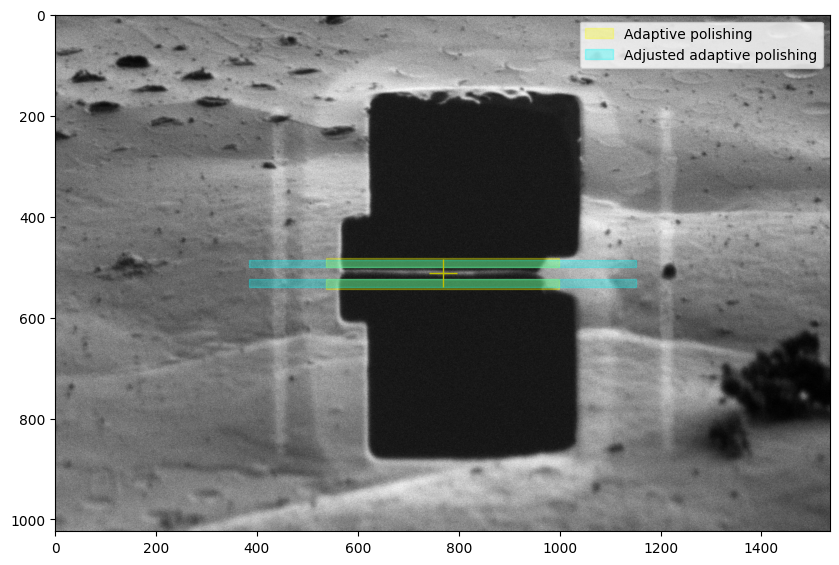

In [9]:
# Place pattern on FIB image from original protocol.yaml file
stages = get_milling_stages("lamella", settings.protocol["milling"])
fig = draw_milling_patterns(ib_image, stages)

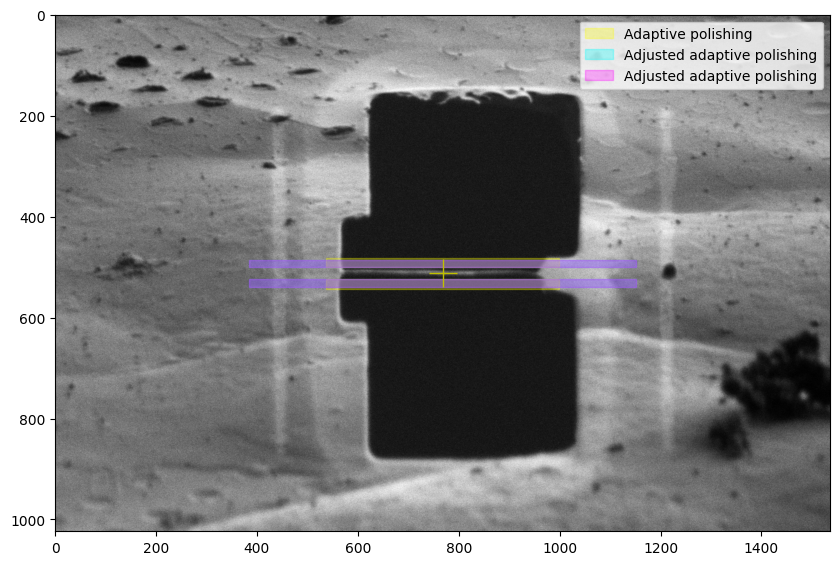

In [13]:
# Place pattern on image from edited pattern
ap_milling_protocol = deepcopy(settings.protocol["milling"]["lamella"]["stages"][-1])
ap_milling_protocol["lamella_width"] = 2e-05
ap_milling_protocol["trench_height"] = 4e-7
ap_milling_protocol["name"] = "Adjusted adaptive polishing"
if settings.protocol["milling"]["lamella"]["stages"][-1]["name"] == "Adaptive polishing":
    settings.protocol["milling"]["lamella"]["stages"].append(ap_milling_protocol)
elif settings.protocol["milling"]["lamella"]["stages"][-1]["name"] == "Adjusted adaptive polishing":
    settings.protocol["milling"]["lamella"]["stages"][-1] = ap_milling_protocol
stages = get_milling_stages("lamella", settings.protocol["milling"])
fig = draw_milling_patterns(ib_image, stages)

In [14]:
# Find the lamella width based on SEM image segmentation


In [ ]:
# Test that the milling part of it works?